# 03 — Evaluation & Model Comparison

This notebook evaluates trained models on the NuminaMath-CoT test set and
provides a head-to-head comparison between the SFT and RL (GRPO) models.

**Metrics:** Exact-match accuracy on `\boxed{}` answers with symbolic equality fallback.

## 1. Setup

In [1]:
!git clone https://github.com/Roogard/math-rl-tuning.git
%cd math-rl-tuning

# Install the package
!pip install -e ".[viz]" --quiet
!pip install bitsandbytes latex2sympy2 --quiet
!pip install math-verify

Cloning into 'math-rl-tuning'...
remote: Enumerating objects: 437, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 437 (delta 43), reused 59 (delta 26), pack-reused 352 (from 1)
Receiving objects: 100% (437/437), 4.21 MiB | 10.09 MiB/s, done.
Resolving deltas: 100% (267/267), done.
/content/math-rl-tuning
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.8/89.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 52.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
omegaconf 2.3.0 requires antlr4-python3-runtime==

In [2]:
from math_rl_tuning.config import load_config
from math_rl_tuning.utils import setup_hf_token, mount_google_drive

cfg = load_config()
setup_hf_token()
mount_google_drive()

Mounted at /content/drive


## 2. Configure Model Paths

In [3]:
# Point these to your saved adapters (local or Google Drive)
#SFT_ADAPTER_PATH = cfg.paths.sft_output_dir
#RL_ADAPTER_PATH = cfg.paths.grpo_output_dir

# Or use Drive paths:
SFT_ADAPTER_PATH = "/content/drive/MyDrive/math-rl-tuning/sft"
RL_ADAPTER_PATH = "/content/drive/MyDrive/math-rl-tuning/grpo"

NUM_SAMPLES = 100  # Number of test examples to evaluate

## 3. Load Test Data

In [4]:
from math_rl_tuning.data import prepare_test_data

test_ds = prepare_test_data(cfg)
print(f"Test examples: {len(test_ds)}")
print(f"Sample problem: {test_ds[0]['problem'][:200]}...")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00005.parquet:   0%|          | 0.00/247M [00:00<?, ?B/s]

data/train-00001-of-00005.parquet:   0%|          | 0.00/247M [00:00<?, ?B/s]

data/train-00002-of-00005.parquet:   0%|          | 0.00/247M [00:00<?, ?B/s]

...

data/train-00004-of-00005.parquet:   0%|          | 0.00/247M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/166k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/859494 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

Test set size: 59
Test set sources: ['cn_k12', 'gsm8k', 'math', 'orca_math']
Test examples: 59
Sample problem: Given the function $f(x)=|x+1|-|x-2|$.
$(1)$ Find the solution set of the inequality $f(x)\geqslant 1$;
$(2)$ If the solution set of the inequality $f(x)\geqslant x^{2}-x+m$ is non-empty, find the ran...


## 4. Evaluate a Single Model

Use this to evaluate just one model (SFT or RL).

In [5]:
from math_rl_tuning.evaluation import evaluate_adapter

sft_df, sft_acc = evaluate_adapter(
    adapter_path=SFT_ADAPTER_PATH,
    test_dataset=test_ds,
    cfg=cfg,
    num_samples=NUM_SAMPLES,
    model_name="SFT",
)

print(f"\nSFT Accuracy: {sft_acc:.2%}")
sft_df.head(10)


Loading adapter: /content/drive/MyDrive/math-rl-tuning/sft
BnB compute dtype: torch.bfloat16
Loading base model: Qwen/Qwen2.5-7B-Instruct


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Loading adapter: /content/drive/MyDrive/math-rl-tuning/sft
Evaluating SFT on 59 examples (batch_size=16)...



Batches:   0%|          | 0/4 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.

Batches: 100%|██████████| 4/4 [13:06<00:00, 196.63s/it]


SFT Accuracy: 0.5254  (31/59)
Memory cleared.

SFT Accuracy: 52.54%


,model,problem_snippet,ground_truth,predicted,is_correct,full_output
0,SFT,Given the function $f(x)=|x+1|-|x-2|$.\n$(1)$ ...,"(-\infty, \dfrac {5}{4}]","(-\infty, \frac {5}{4}]",True,Solution:\n$(1)$ The function $f(x)=|x+1|-|x-2...
1,SFT,4 pints of a 5% antifreeze solution and 8 pint...,15\%,15\%,True,"To solve this problem, we start by calculating..."
2,SFT,what is the sum of 100 consecutive integers fr...,50,50,True,To find the sum of 100 consecutive integers st...
3,SFT,The average math scores of classes A and B are...,B,B,True,To determine Xiaoming's possible math score af...
4,SFT,Billy worked for 3 straight hours on his homew...,3:1,2,False,"To solve this problem, we start by understandi..."
5,SFT,All the students of the class are told to sit ...,70,70,True,"To solve this problem, we need to understand t..."
6,SFT,Let the function $f(x)=\sin (4x+ \frac {\pi}{4...,B,B,True,"Since $x\in[0, \frac {9\pi}{16}]$, we have $4x..."
7,SFT,Given the set $M={x|y=\sqrt{-x^2+2x+8}}$ and t...,\text{A: } {x|-2 \leqslant x \leqslant 4},A,False,"To find the intersection of sets $M$ and $N$, ..."
8,SFT,"While playing a game, Kaleb had 98 lives. Afte...",73,73,True,"To solve this problem, we start with the total..."
9,SFT,Consider a sequence $\{a_n\}$ defined as follo...,31^2 + 47 = 1008,2000,False,(1) The sequence $\{a_n\}$ can be divided into...


## 5. Head-to-Head Comparison (Base vs SFT vs RL)

In [6]:
from math_rl_tuning.evaluation import compare_models, save_results

results = compare_models(
    sft_adapter_path=SFT_ADAPTER_PATH,
    rl_adapter_path=RL_ADAPTER_PATH,
    test_dataset=test_ds,
    cfg=cfg,
    num_samples=NUM_SAMPLES,
)

# Save results to disk
save_results(results, cfg.paths.eval_output_dir)

  HEAD-TO-HEAD MODEL COMPARISON

Loading base model: Qwen/Qwen2.5-7B-Instruct
Loading tokenizer: Qwen/Qwen2.5-7B-Instruct


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

SFT Accuracy: 0.5254  (31/59)

Loading RL adapter: /content/drive/MyDrive/math-rl-tuning/grpo


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Evaluating RL (GRPO) on 59 examples (batch_size=16)...



Batches: 100%|██████████| 4/4 [23:50<00:00, 357.59s/it]


RL (GRPO) Accuracy: 0.6610  (39/59)
Memory cleared.

  RESULTS
Base Accuracy:      64.41%
SFT Accuracy:       52.54%  (-11.86% vs Base)
RL (GRPO) Accuracy: 66.10%  (+13.56% vs SFT)

SFT fixed 4 Base errors, regressed on 11.
RL fixed 10 SFT errors, regressed on 2.
Summary saved to: ./outputs/eval/summary.json
base_results saved to: ./outputs/eval/base_results.csv
sft_results saved to: ./outputs/eval/sft_results.csv
rl_results saved to: ./outputs/eval/rl_results.csv


## 6. Visualize Results

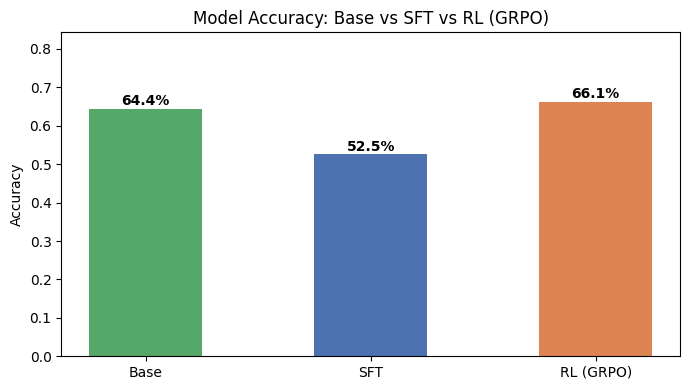

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Bar chart: accuracy comparison across all three models
fig, ax = plt.subplots(figsize=(7, 4))

model_labels = []
accuracies = []
colors = []

if "base_accuracy" in results:
    model_labels.append("Base")
    accuracies.append(results["base_accuracy"])
    colors.append("#55A868")

model_labels += ["SFT", "RL (GRPO)"]
accuracies += [results["sft_accuracy"], results["rl_accuracy"]]
colors += ["#4C72B0", "#DD8452"]

bars = ax.bar(model_labels, accuracies, color=colors, width=0.5)
ax.set_ylabel("Accuracy")
ax.set_title("Model Accuracy: Base vs SFT vs RL (GRPO)")
ax.set_ylim(0, max(accuracies) * 1.2 + 0.05)

for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{acc:.1%}",
        ha="center",
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150)
plt.show()

In [8]:
def show_comparison(df, col_a, col_b, label_a, label_b):
    """Print cases where model B fixed model A's errors, and vice versa."""
    gains = df[(~df[f"{col_a}_correct"]) & df[f"{col_b}_correct"]]
    regressions = df[df[f"{col_a}_correct"] & (~df[f"{col_b}_correct"])]
    print(f"{label_b} fixed {len(gains)} {label_a} errors, regressed on {len(regressions)}.")
    if not gains.empty:
        print(f"\n=== {label_b} Improvements over {label_a} ===")
        display(gains[["problem_snippet", "ground_truth"]].reset_index(drop=True))

# Base → SFT
if "base_vs_sft" in results:
    print("── Base → SFT ──────────────────────────────")
    show_comparison(results["base_vs_sft"], "Base", "SFT", "Base", "SFT")

# SFT → RL
if "sft_vs_rl" in results:
    print("\n── SFT → RL ────────────────────────────────")
    show_comparison(results["sft_vs_rl"], "SFT", "RL", "SFT", "RL")

── Base → SFT ──────────────────────────────
SFT fixed 4 Base errors, regressed on 11.

=== SFT Improvements over Base ===


,problem_snippet,ground_truth
0,Given the function $f(x)=|x+1|-|x-2|$.\n$(1)$ ...,"(-\infty, \dfrac {5}{4}]"
1,Let the function $f(x)=\sin (4x+ \frac {\pi}{4...,B
2,A train that is 510 meters long is running at ...,45
3,Elective 4-4: Coordinate System and Parametric...,"\left(\frac{3}{2}, \frac{1}{2}\right)"



── SFT → RL ────────────────────────────────
RL fixed 10 SFT errors, regressed on 2.

=== RL Improvements over SFT ===


,problem_snippet,ground_truth
0,Billy worked for 3 straight hours on his homew...,3:1
1,"Given the planar vectors $\vec{a}=(2,4)$, $\ve...","(3,6)"
2,The distance from the center of the circle \\(...,\text{A}
3,What is the largest multiple of 10 for which t...,\(10n
4,A and B participate in a shooting game. Accord...,\text{D}
5,Given that the line $y=kx$ is a tangent to the...,\dfrac{1}{e}
6,Given a sequence ${a_n}$ with the sum of its f...,768
7,"In a renowned city, the average birth rate is ...",4
8,"Given that $a$, $b$, $c$ are all positive numb...",\frac{a}{{b+c}} + \frac{b}{{a+c}} + \frac{c}{{...
9,Ten identical crates each of dimensions $3\mat...,190


## 7. Cleanup

In [9]:
from math_rl_tuning.utils import clean_memory
clean_memory()

Memory cleared.
